In [ ]:
import importlib
import math
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import umap
import hdbscan

import nltk
from nltk.corpus import stopwords

from bertopic import BERTopic
from joblib import Parallel, delayed
from langdetect import detect
from scipy.stats import chi2_contingency
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tqdm import tqdm

import src.fct_data
importlib.reload(src.fct_data)
from src.fct_data import raw_data_cleaning

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Extraction des données



Traitement pour les 5 années disponibles sur le `gitlab` 

In [ ]:
#on récupère un df avec métadonnées + texte nettoyé des stopwords
meta_et_texts=raw_data_cleaning("data/archelect_search.zip","data/text_files")

/home/onyxia/work/NLP_3A/src/fct_data.py:12: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  metadonnees = pd.read_csv("data/archelect_search.zip", compression="zip")


Traitement de data/text_files/1988/legislatives.zip
Traitement de data/text_files/1978/legislatives.zip
Traitement de data/text_files/1981/legislatives.zip
Traitement de data/text_files/1993/legislatives.zip
Traitement de data/text_files/1993/presidentielle.zip
Traitement de data/text_files/1973/legislatives.zip
Nombre total de documents extraits : 21697


[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-t

## 1/ Thematic propensity by party
#### _For a specific election, calculate the distribution of themes for each political side._


We propose and compare 2 approches : (i) Non-negative matrix factorisation, (ii) Topic modeling with embeddings : Bertopic


In [ ]:
# cleaning 
df = meta_et_texts.dropna(subset=['text']).copy() #remove lines without texts
df = df[df['text'].str.strip() != ''].copy() #same for lines with empty text

df = df.reset_index(drop=True)
df['annee'] = pd.to_datetime(df['date'], errors='coerce').dt.year
df = df[df["annee"].isin([1981, 1988, 1993])].copy()

We check the size of our texts for a better choixe of model

In [5]:
lengths = df['text'].str.split().str.len()

print("Moyenne :", lengths.mean())
print("Médiane :", lengths.median())
print("Max :", lengths.max())
print("Min :", lengths.min())

Moyenne : 634.708089941586
Médiane : 563.0
Max : 3232
Min : 27


#### (i) Non-negative matrix factorisation

In [6]:
# lemmatisation : 6 min pour 1 election
# python -m spacy download fr_core_news_sm A INSTALLER A LA PREMIERE UTILISATION

start_load = time.time()

nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])

print(f"Modèle chargé en {time.time() - start_load:.2f}s\n")

def lemmatize_batch(texts, batch_size=1000):
    total_docs = len(texts)
    print(f"Début de la lemmatisation de {total_docs} documents\n")

    start_total = time.time()
    results = []

    processed = 0
    batch_id = 0

    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=2):
        lemmas = " ".join(
            token.lemma_.lower()
            for token in doc
            if not token.is_stop and token.is_alpha and len(token) > 2
        )
        results.append(lemmas)

        processed += 1

        # print tous les 1000 docs
        if processed % 1000 == 0:
            elapsed = time.time() - start_total
            speed = processed / elapsed
            print(f"{processed}/{total_docs} docs | {speed:.1f} docs/sec | {elapsed/60:.2f} min")

    total_time = time.time() - start_total

    print("\nLemmatisation terminée")
    print(f"Documents traités : {total_docs}")
    print(f"Temps total : {total_time/60:.2f} min")

    return results


# Application
df['lemmatized_text'] = lemmatize_batch(df['text'].tolist())

Modèle chargé en 11.33s

Début de la lemmatisation de 12497 documents

1000/12497 docs | 7.7 docs/sec | 2.16 min
2000/12497 docs | 14.1 docs/sec | 2.37 min
3000/12497 docs | 12.2 docs/sec | 4.11 min
4000/12497 docs | 13.5 docs/sec | 4.93 min
5000/12497 docs | 13.1 docs/sec | 6.38 min
6000/12497 docs | 13.4 docs/sec | 7.48 min
7000/12497 docs | 13.9 docs/sec | 8.39 min
8000/12497 docs | 14.0 docs/sec | 9.54 min
9000/12497 docs | 14.3 docs/sec | 10.46 min
10000/12497 docs | 14.2 docs/sec | 11.76 min
11000/12497 docs | 14.2 docs/sec | 12.91 min
12000/12497 docs | 14.7 docs/sec | 13.63 min

Lemmatisation terminée
Documents traités : 12497
Temps total : 13.69 min


On sauvegarde les données intermédiaires pour gagner du temps dans l'exécution et pouvoir les récupérer directement depuis data/inter

In [ ]:
#df.to_parquet("data/inter/df_lemmatized.parquet", engine="pyarrow", index=False, compression="snappy")

In [8]:
df = pd.read_parquet("data/inter/df_lemmatized.parquet")

In [ ]:
#nltk.download('stopwords')

# NMF global (tous élections confondues)
N_TOPICS = 6

#stopwords 
custom_stopwords = [
    # Mots génériques non thématiques
    "monsieur", "madame", "politique", "france", "français", "françaises",
    "faire", "être", "avoir", "falloir", "pouvoir", "devoir",
    "ici", "nom", "vie", "année","bulletin","pays","électeur","liste",
    "député","gauche","droite","majorité","parti","juin","gouvernement",
    "maire","président","marseille",
    
    # Étiquettes de partis / personnes
    "rpr", "udf", "communiste", "socialiste", "ecologiste", "écologiste",
    "lepen", "mitterrand", "ruffi","françois","mitterrand",
    "front", "national", 
] + stopwords.words('german')+ stopwords.words('french')


# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.5,   #  on supprime les mots présents dans plus de la moitié des textes
    min_df=15,     # on supprime ceux dans moins de 15 textes
    max_features = 20000, #on limite la taille des mots à enregistrer
    stop_words=custom_stopwords,  
)
tfidf = tfidf_vectorizer.fit_transform(df['lemmatized_text'])
print('tf-idf fini')
# Non-negative matrix factorisation
nmf = NMF(n_components=N_TOPICS, random_state=2026)
W = nmf.fit_transform(tfidf)
H = nmf.components_
print(' NMF fini')

# Affichage des mots par topic
feature_names = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(nmf.components_):
    top_words = [feature_names[i] for i in np.argsort(-topic)[:20]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}\n")

# Normalisation
W_normalized = W / W.sum(axis=1, keepdims=True)
df['dominant_topic'] = np.argmax(W_normalized, axis=1)
df['topic_score']    = np.max(W_normalized, axis=1)

# Ajout des poids au dataframe
topic_cols = [f'topic_{i}' for i in range(N_TOPICS)]
W_df = pd.DataFrame(W_normalized, columns=topic_cols)
df = pd.concat([df.reset_index(drop=True), W_df], axis=1)

In [ ]:
# labels input
topic_label = {
    0: "appel à l'alternance",
    1: "protection de l'environnement et des animaux",
    2: 'fiscalité',
    3: 'immigration',
    4: 'lutte sociale', 
    5: 'écologie et générations futures'
}

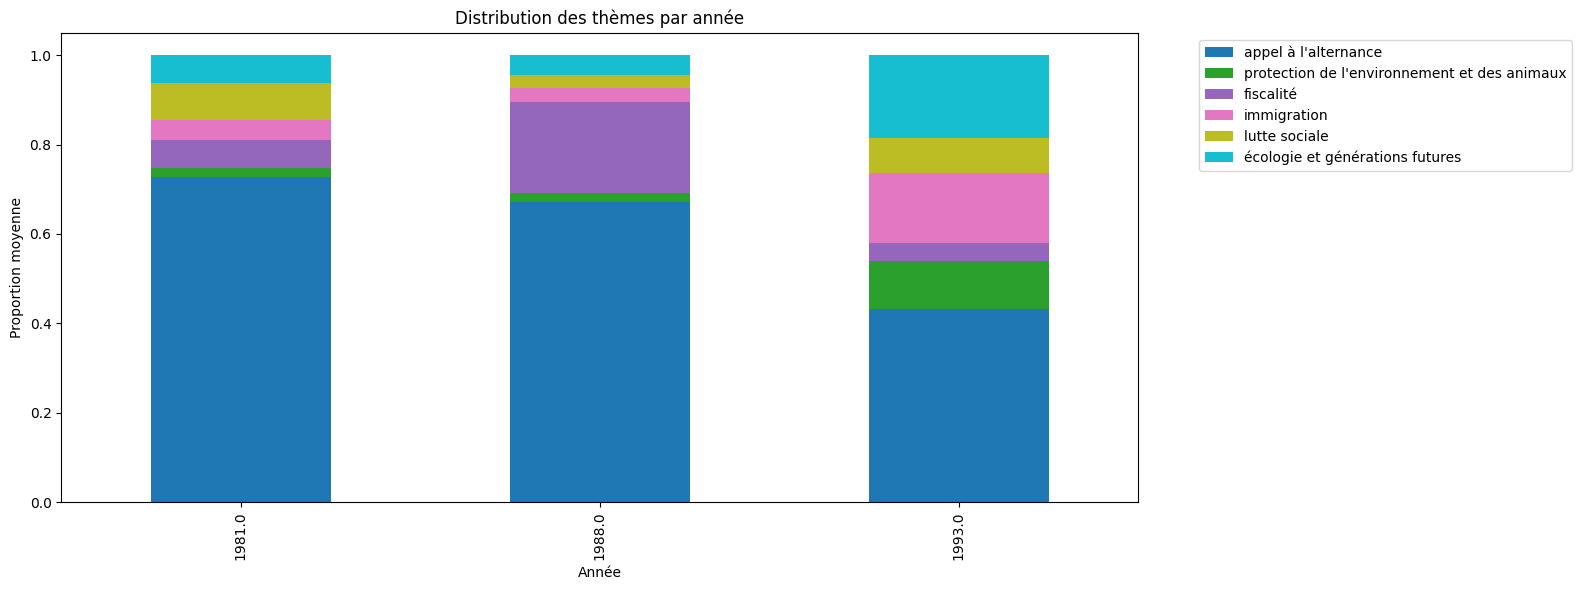

In [51]:
# topics / doc 


W_normalized = W / W.sum(axis=1, keepdims=True)

df['dominant_topic'] = np.argmax(W_normalized, axis=1)
df['dominant_label'] = df['dominant_topic'].map(topic_label)
df['topic_score']    = np.max(W_normalized, axis=1)

# topic distrib / year 
topic_cols = [f'topic_{i}' for i in range(N_TOPICS)]

# ajout colonnes
df = df.drop(columns=[col for col in df.columns if col.startswith('topic_')], errors='ignore')
W_df = pd.DataFrame(W_normalized, columns=topic_cols)
df = pd.concat([df.reset_index(drop=True), W_df], axis=1)

topic_by_year = df.groupby('annee')[topic_cols].mean()

topic_by_year.rename(
    columns={f'topic_{i}': topic_label[i] for i in range(N_TOPICS)}
).plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    colormap='tab10'
)
plt.title("Distribution des thèmes par année")
plt.ylabel("Proportion moyenne")
plt.xlabel("Année")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


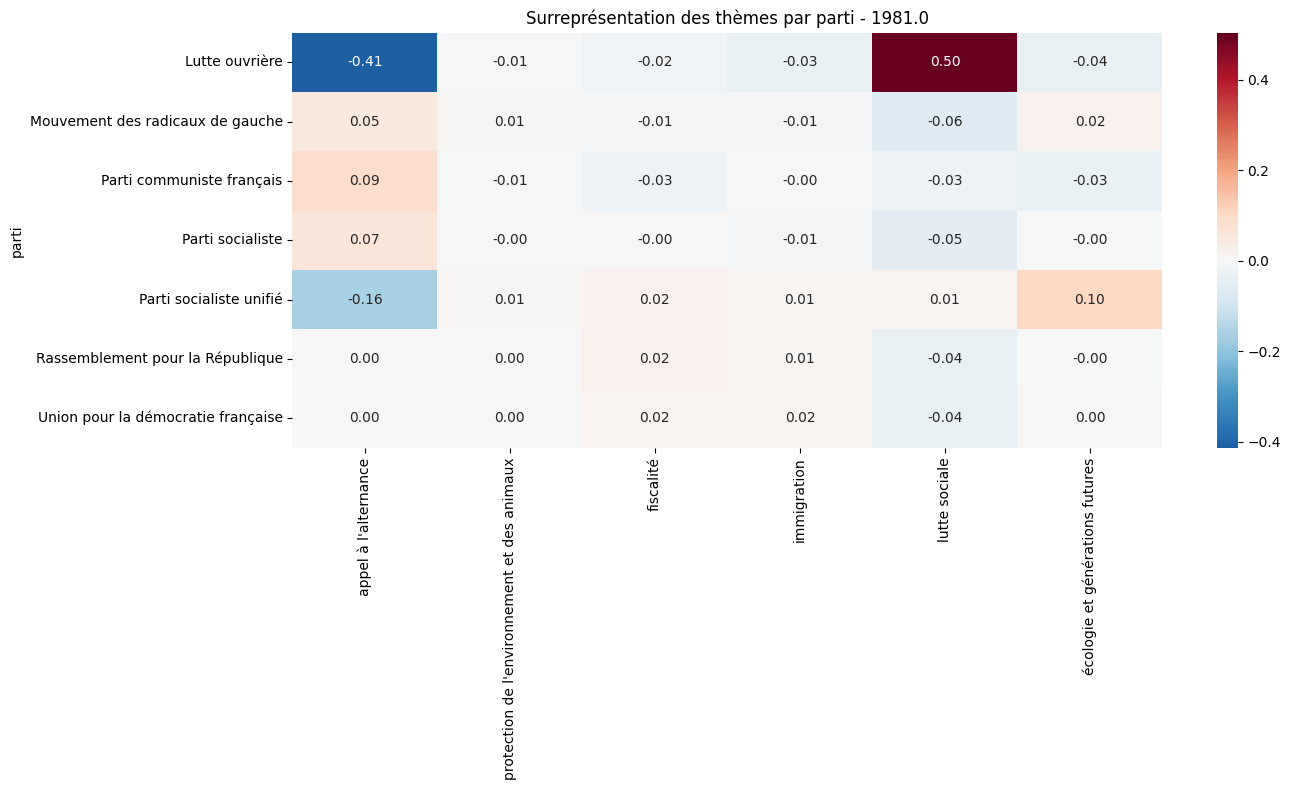

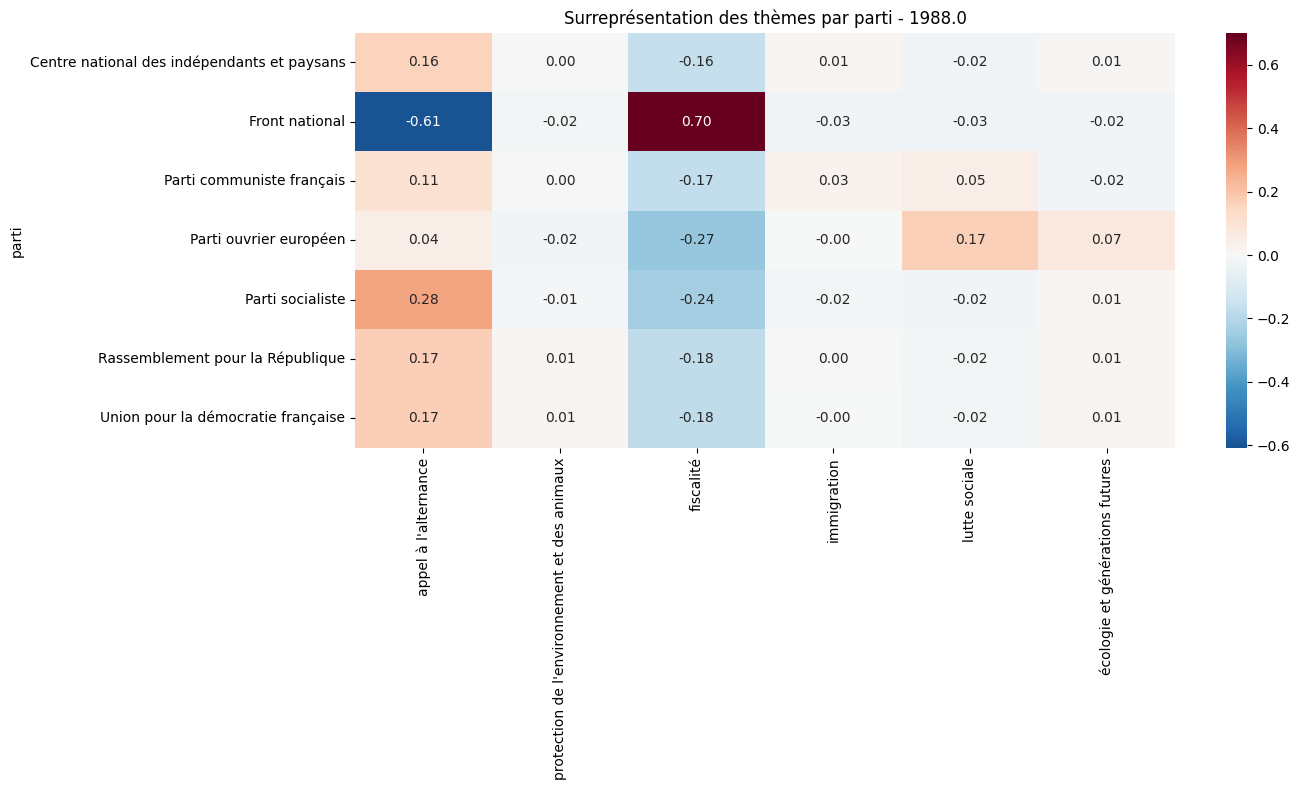

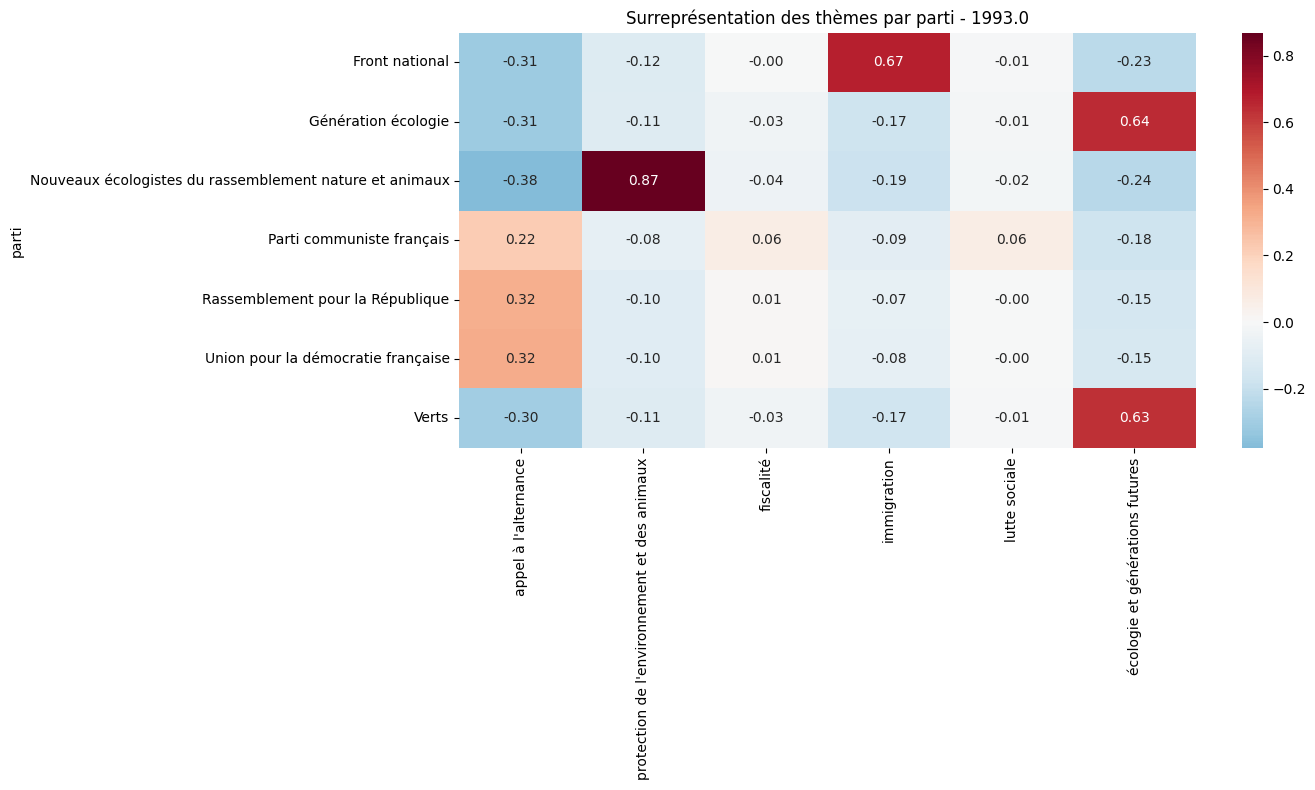

In [52]:
# créer un DataFrame explosé pour les partis
df_exploded = df.copy()
df_exploded['parti'] = df_exploded['titulaire-soutien'].str.split(';')
df_exploded = df_exploded.explode('parti')
df_exploded['parti'] = df_exploded['parti'].str.strip()
df_exploded = df_exploded[df_exploded['parti'].notna()]
df_exploded = df_exploded[df_exploded['parti'] != "non mentionné"]
df_exploded = df_exploded[df_exploded['parti'] != ""]

# boucle par année
for year, df_year in df_exploded.groupby('annee'):

    # compter les partis pour cette année et garder top nb_partis
    nb_partis = 7
    parti_counter = Counter(df_year['parti'])
    top_partis = [p for p, _ in parti_counter.most_common(nb_partis)]
    df_top = df_year[df_year['parti'].isin(top_partis)]

    # calcul surreprésentation
    global_mean = df_top[topic_cols].mean()
    topic_by_parti = df_top.groupby('parti')[topic_cols].mean()
    surreprésentation = topic_by_parti - global_mean

    # heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        surreprésentation.rename(
            columns={f'topic_{i}': topic_label[i] for i in range(N_TOPICS)}
        ),
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f'
    )
    plt.title(f"Surreprésentation des thèmes par parti - {year}")
    plt.tight_layout()
    plt.show()

#### (ii) Topic modeling with embeddings : Bertopic

In [53]:
#cleaning
mask = df['text'].notna() & (df['text'].str.strip() != '')
df   = df[mask].reset_index(drop=True)
docs = df['text'].tolist()

# embeddings //
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

num_cores  = -1
chunk_size = 500
batch_size = 32
chunks     = [docs[i:i+chunk_size] for i in range(0, len(docs), chunk_size)]
num_chunks = len(chunks)
print(f"Nombre total de chunks : {num_chunks}")

def encode_chunk(chunk, chunk_idx):
    start      = time.time()
    embeddings = embedding_model.encode(chunk, batch_size=batch_size, convert_to_numpy=True)
    elapsed    = time.time() - start
    print(f"Chunk {chunk_idx+1}/{num_chunks} traité en {elapsed:.2f}s")
    return embeddings, elapsed

start_total    = time.time()
results        = Parallel(n_jobs=num_cores, prefer="threads")(
    delayed(encode_chunk)(chunk, idx) for idx, chunk in enumerate(chunks)
)
embeddings     = np.vstack([res[0] for res in results])
total_time     = time.time() - start_total

print(f"\n Embeddings générés pour {len(docs)} textes")
print(f"Shape : {embeddings.shape}")
print(f"Temps total : {total_time/60:.2f} minutes")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 775.07it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Nombre total de chunks : 25
Chunk 10/25 traité en 109.88s
Chunk 8/25 traité en 111.26s
Chunk 14/25 traité en 113.56s
Chunk 4/25 traité en 116.07s
Chunk 6/25 traité en 117.77s
Chunk 7/25 traité en 118.85s
Chunk 13/25 traité en 119.49s
Chunk 1/25 traité en 120.80s
Chunk 2/25 traité en 121.03s
Chunk 11/25 traité en 121.73s
Chunk 3/25 traité en 122.12s
Chunk 15/25 traité en 122.34s
Chunk 5/25 traité en 122.52s
Chunk 9/25 traité en 122.76s
Chunk 12/25 traité en 124.83s
Chunk 18/25 traité en 77.76s
Chunk 17/25 traité en 80.96s
Chunk 16/25 traité en 82.63s
Chunk 19/25 traité en 76.81s
Chunk 25/25 traité en 71.88s
Chunk 24/25 traité en 73.50s
Chunk 22/25 traité en 75.22s
Chunk 20/25 traité en 77.24s
Chunk 23/25 traité en 74.20s
Chunk 21/25 traité en 76.27s

 Embeddings générés pour 12497 textes
Shape : (12497, 384)
Temps total : 3.27 minutes


In [54]:
nltk.download('stopwords')
STOPWORDS = stopwords.words('french')+stopwords.words('german')

word_counter = Counter()
for doc in docs:
    word_counter.update(doc.lower().split())

# top 30 mots les plus fréquents hors stopwords
top = [
    word for word, _ in word_counter.most_common(200)
    if word not in STOPWORDS
][:60] #jusqu'à 65 les mots sont peu informatifs

print("Mots les plus fréquents à retirer :", top)

STOPWORDS = list(set(STOPWORDS + top))

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Mots les plus fréquents à retirer : ['-', ':', '·', 'a', 'plus', '/', 'fonds', 'po', "c'est", 'cevipof', 'politique', 'tous', 'france', 'sciences', 'faire', '☐', 'candidat', 'circonscription', 'comme', '!', ';', '...', 'faut', 'majorité', 'français', 'contre', 'cette', 'tout', 'parti', 'sans', 'leurs', 'juin', 'votez', 'toutes', "d'une", 'conseiller', 'gauche', 'si', 'droite', 'député', 'être', 'candidats', 'vie', 'ceux', "d'un", 'ans', 'législatives', 'suppléant', 'depuis', '21', 'nouvelle', 'mars', 'maire', 'élections', 'fait', '5', 'vote', 'voter', '?', 'président']


In [57]:
# UMAP et HDBScan // 
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.2,
    n_components=5,
    random_state=42,
    n_jobs=-1
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=50,
    cluster_selection_epsilon=0.01,
    core_dist_n_jobs=-1,
    prediction_data=True  
)

# Bertopic
vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS,
    min_df=3
)

topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language='french',
    nr_topics=10,
    calculate_probabilities=True,
)

topics, probs = topic_model.fit_transform(docs, embeddings=embeddings) #  BERTopic l'embeddings car déjà fait

# ajout au df
print(topic_model.get_topic_info())

df['BERTopic_dominant'] = topics
df['BERTopic_score']    = probs.max(axis=1)

   Topic  Count                                        Name  \
0     -1    351   -1_travailleurs_patrons_emplois_maintenir   
1      0  10702               0_pays_nationale_jean_sociale   
2      1    389            1_national_front_nationale_force   
3      2    362     2_nature_animaux_nouveaux_rassemblement   
4      3    173          3_patrons_maintenir_payer_patronat   
5      4    154  4_mitterrand_ouvrière_travailleurs_députés   
6      5    131              5_national_front_nationale_udf   
7      6     90          6_accepter_pouvons_illusion_europe   
8      7     86                 7_travailleurs_unité_lcr_ps   
9      8     59                    8_12_refus_maintien_mise   

                                      Representation  \
0  [travailleurs, patrons, emplois, maintenir, en...   
1  [pays, nationale, jean, sociale, union, vu, em...   
2  [national, front, nationale, force, udf, rpr, ...   
3  [nature, animaux, nouveaux, rassemblement, exi...   
4  [patrons, maintenir, pa

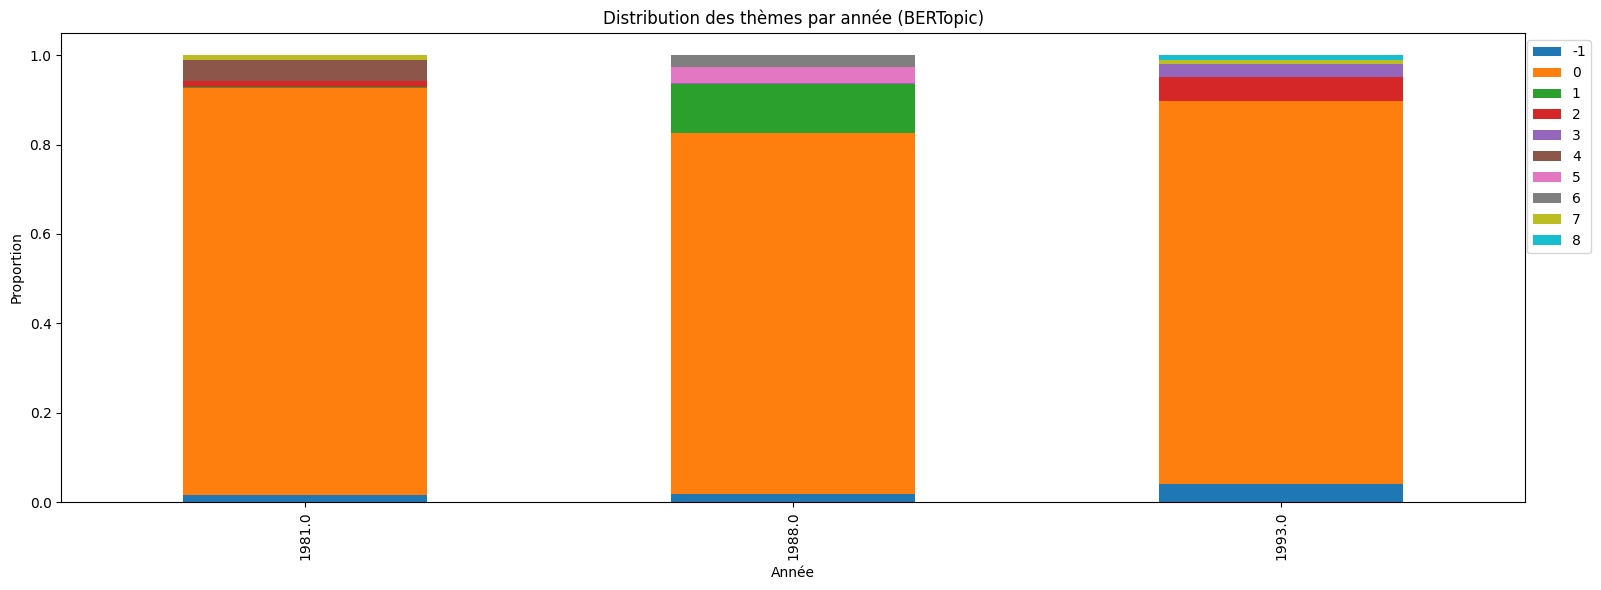

In [58]:
#distrib topic par année
topic_info = topic_model.get_topic_info().set_index('Topic')['Name'].to_dict()

topic_by_year = df.groupby(['annee', 'BERTopic_dominant']).size().unstack(fill_value=0)
topic_by_year = topic_by_year.div(topic_by_year.sum(axis=1), axis=0)  # normalisation

topic_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    colormap='tab10'
)
plt.title("Distribution des thèmes par année (BERTopic)")
plt.ylabel("Proportion")
plt.xlabel("Année")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### (ii bis) Bertopic par Caroline (très similaire à ce que j'ai fait au dessus) 
@caroline : mon BERT fonctionne très mal, cf. graphique d'au dessus par rapport à celui de NMF qui n'a pas un cluster qui écrase tout le monde.
il faudrait voir si c'est pareil pour ton code 

In [14]:
#  Chargement de stopwords français
try:
    nlp = spacy.load("fr_core_news_sm")
except:
    !python -m spacy download fr_core_news_sm
    nlp = spacy.load("fr_core_news_sm")

stopwords_fr = nlp.Defaults.stop_words

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 39.4 MB/s  0:00:00m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


In [15]:
# Identification des mots les plus fréquents

# On concatène tous les textes
all_text = " ".join(meta_et_texts['texte_clean'].astype(str)).lower()
# retirer ponctuation
all_text = re.sub(r"[^\w\s]", " ", all_text)
tokens = all_text.split()
# compter les mots
word_counts = Counter(tokens)
# choisir les 20 mots les plus fréquents à exclure
top_20_words = [w for w, c in word_counts.most_common(20)]
print("Mots les plus fréquents à retirer :", top_20_words)

Mots les plus fréquents à retirer : ['plus', 'a', 'cest', 'fonds', 'po', 'tous', 'politique', 'ans', 'circonscription', 'gauche', 'cevipof', 'france', 'candidat', 'sciences', 'parti', 'mars', 'travailleurs', 'français', 'comme', 'faire']


In [21]:
meta_et_texts=meta_et_texts[meta_et_texts["date"]=="1981-06-14"].copy()

In [22]:
# Fonction de prétraitement
def preprocess_text(text, stopwords=set(), top_words=set()):
    text = str(text).lower()
    # retirer ponctuation et chiffres
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    # tokenizer
    tokens = text.split()
    # filtrer stopwords et top_words
    tokens = [t for t in tokens if t not in stopwords and t not in top_words]
    return " ".join(tokens)


# On applique cette fonction sur le corpus
meta_et_texts['texte_clean_filtered'] = meta_et_texts['texte_clean'].apply(
    lambda x: preprocess_text(x, stopwords_fr, set(top_20_words))
)
texts = meta_et_texts['texte_clean_filtered'].tolist()  # liste pure Python

In [23]:
# On charge un modèle multilangue
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device='cpu')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 651.68it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
# Définition des paramètres
chunk_size = 1000       # taille des chunks pour parallélisation
batch_size = 2048       # batch_size à l'intérieur du modèle
num_cores = 48          # nombre de threads CPU à utiliser pour joblib

Prend environ 2min grâce à la parallélisation

In [25]:
# découper en chunks
chunks = [texts[i:i+chunk_size] for i in range(0, len(texts), chunk_size)]
num_chunks = len(chunks)

print(f"Nombre total de chunks : {num_chunks}")

# Fonction pour encoder un chunk
def encode_chunk(chunk, chunk_idx):
    start = time.time()
    embeddings = model.encode(chunk, batch_size=batch_size, convert_to_numpy=True)
    end = time.time()
    elapsed = end - start
    print(f"✅ Chunk {chunk_idx+1}/{num_chunks} traité en {elapsed:.2f}s")
    return embeddings, elapsed


# Encodage parallèle pour exploiter la puissance d'Onyxia et gagner du temps (avec suivi du temps pris)
start_total = time.time()

results = Parallel(n_jobs=num_cores)(
    delayed(encode_chunk)(chunk, idx) for idx, chunk in enumerate(chunks)
)

# Séparer embeddings et temps par chunk
embeddings_list = [res[0] for res in results]
chunk_times = [res[1] for res in results]

# Concaténer tous les embeddings
embeddings = np.vstack(embeddings_list)
total_time = time.time() - start_total


# Affichage de quelques statistiques
print(f"\nEmbeddings générés pour {len(texts)} textes")
print(f"Shape des embeddings : {embeddings.shape}")
print(f"Temps total écoulé : {total_time/60:.2f} minutes")
print(f"Temps moyen par chunk : {np.mean(chunk_times):.2f} secondes")
print(f"Temps estimé si encore {num_chunks} chunks : {np.mean(chunk_times)*(num_chunks-1)/60:.2f} minutes")

Nombre total de chunks : 3


✅ Chunk 3/3 traité en 35.86s
✅ Chunk 1/3 traité en 77.12s
✅ Chunk 2/3 traité en 76.93s

Embeddings générés pour 2468 textes
Shape des embeddings : (2468, 384)
Temps total écoulé : 1.49 minutes
Temps moyen par chunk : 63.30 secondes
Temps estimé si encore 3 chunks : 2.11 minutes


#### Classification par thème (suite ii bis BERT caroline)

Ci-dessous, on transforme notre embedding en vecteurs de bcp plus petite dimension (environ 20 sec avec ces paramètre d'UMAP)

In [26]:
umap_embeddings = umap.UMAP(
    n_neighbors=30, min_dist=0.05, n_components=5, random_state=42
).fit_transform(embeddings)
print(f"UMAP embeddings shape: {umap_embeddings.shape}")

UMAP embeddings shape: (2468, 5)


DBScan ci-dessous va créer des clusters thématiques

In [ ]:
print("Clustering avec HDBSCAN...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=50)
#on ajoute à notre dataframe le thème abordé par le candidat
meta_et_texts['theme_cluster'] = clusterer.fit_predict(umap_embeddings)
print(f"Clusters trouvés : {meta_et_texts['theme_cluster'].nunique()} (le -1 correspond aux outliers)")


Clustering avec HDBSCAN...
Clusters trouvés : 2 (le -1 correspond aux outliers)


On essaie de labelliser les thèmes automatiquement

In [30]:

# 1️⃣ Récupérer tes stopwords français et les 10 mots les plus fréquents
# stopwords_fr = set(spacy stopwords) déjà défini
# top_10_words = set() déjà défini

all_stopwords = stopwords_fr.union(top_20_words)  # tous les mots à exclure

# 2️⃣ Fonction pour récupérer les top mots par cluster
def get_top_words_filtered(texts, n=10):
    # concaténer tous les textes du cluster
    all_words = " ".join(texts).lower().split()
    # retirer tous les mots à exclure
    all_words = [w for w in all_words if w not in all_stopwords]
    # compter
    return Counter(all_words).most_common(n)

# 3️⃣ Parcourir les clusters
for cluster_id in sorted(meta_et_texts['theme_cluster'].unique()):
    if cluster_id == -1:  # ignorer les outliers si besoin
        continue
    texts = meta_et_texts[meta_et_texts['theme_cluster'] == cluster_id]['texte_clean_filtered']  # utiliser la colonne filtrée
    top_words = get_top_words_filtered(texts,15)
    print(f"Cluster {cluster_id}: {top_words}")

Cluster 0: [('contre', 322), ('droite', 320), ('faut', 258), ('communiste', 192), ('lcr', 192), ('ps', 164), ('pc', 164), ('giscard', 160), ('majorité', 160), ('lunité', 160), ('revendications', 158), ('candidats', 158), ('voter', 132), ('chômage', 128), ('sils', 128)]
Cluster 1: [('majorité', 7217), ('faut', 4933), ('juin', 4554), ('mitterrand', 4320), ('changement', 4197), ('nouvelle', 3754), ('gouvernement', 3298), ('socialiste', 3098), ('vie', 3022), ('pays', 2762), ('élections', 2697), ('contre', 2663), ('président', 2633), ('nationale', 2574), ('mai', 2554)]


## 2/ Croisement avec les professions des candidats

@caroline pour le moment c'est ton code basé sur ton analyse des thèmes (ie. l'analyse de ii bis)
à voir quelle analyse thématique on garde et donc à adapter en conséquence

Analyse exploratoire

In [13]:
meta_et_texts['titulaire-profession'].nunique()

2032

On a 2032 professions différentes, pas vraiment d'organisation ou de nomenclature déjà déterminée ; on va donc également utiliser de l'embedding et du clustering pour attribuer aux candidats une catégorie plus vaste de métier

In [ ]:
#cleaning en préambule
professions = meta_et_texts['titulaire-profession'].dropna()
professions_clean = (
    professions
    .str.lower()
    .str.strip()
    #la ligne ci-dessous permet de supprimer le point-virgule séparant les différents métiers déclarés par une même personne
    .str.replace(";", " ", regex=False) 

)
unique_professions = professions_clean.unique()

def clean_prof(x):
    x = re.sub(r"[^\w\s-]", "", x)
    return x

unique_professions = [clean_prof(p) for p in unique_professions]
len(unique_professions)

2029

In [ ]:
#Embedding des métiers
model_professions = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings_professions = model_professions.encode(unique_professions,batch_size=256,show_progress_bar=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 971.46it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 8/8 [01:31<00:00, 11.45s/it]


In [ ]:
from sklearn.cluster import KMeans

n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

clusters = kmeans.fit_predict(embeddings_professions)
prof_cluster_df = pd.DataFrame({
    "profession": unique_professions,
    "cluster": clusters
})

In [27]:
cluster_map = dict(zip(prof_cluster_df.profession, prof_cluster_df.cluster))

meta_et_texts["profession_clean"] = (
    meta_et_texts["titulaire-profession"]
    .str.lower()
    .str.strip()
)

meta_et_texts["profession_cluster"] = (
    meta_et_texts["profession_clean"]
    .map(cluster_map)
)

In [28]:
#Analyse des clusters
for i in range(n_clusters):
    print("\nCluster", i)
    print(prof_cluster_df[prof_cluster_df.cluster == i].profession.tolist())


Cluster 0
['ingénieur', 'technicien cadre multinationale', 'ingénieur informaticien', 'ingénieur-conseil urbaniste', 'technicien', 'ingénieur industrie', 'agréé architecture', 'ingénieur divisionnaire', 'directeur technique cnasea', 'ingénieur chimiste', 'architecte', 'technicienne recherche', 'ingénieur commercial informatique', 'ingénieur civil', 'ingénieur économiste', 'architecte-urbaniste', 'ingénieur président centre de formation professionnelle', 'ingénieur-conseil', 'électronicien', 'ingénieur en chef ponts et chaussées', 'technicien tdf', 'ingénieur ponts et chaussées', 'ingénieur électronicien', 'ingénieur détudes université', 'chauffeur chaudière', 'responsable industriel', 'ingénieur civil ponts et chaussées administrateur insee', 'conducteur de travaux', 'ouvrier électricien', 'ingénieur thermicien assimilé', 'technicien atelier', 'ouvrier métallurgiste', 'architecte dplg', 'ingénieur industriel', 'ingénieur commercial', 'ouvrier laboratoire photographique', 'technicien p

In [29]:
cluster_labels = {
0: "ingenieur",
1: "commercant_cadre_commercial",
2: "chef",
3: "technicien",
4: "legal",
5: "artisan_artistique",
6: "education_nationale",
7: "agriculture",
8: "medecine",
9: "professions_intell_superieures",
10: "militaire",
11: "divers"
}

On ajoute les catégories des métiers au dataframe de base

In [30]:
meta_et_texts["profession_category"] = (
    meta_et_texts["profession_cluster"]
    .map(cluster_labels)
)

### Analyse conjointe des sujets des professions de foi et des métiers

In [69]:
pd.crosstab(
    meta_et_texts["profession_category"],
    meta_et_texts["theme_cluster"],
    normalize="index"
)

theme_cluster,-1,0,1,2,3,4,5,7,8,9,10,11,12,13
profession_category,,,,,,,,,,,,,,
agriculture,0.000000,0.000000,0.018519,0.000000,0.000000,0.000000,0.018519,0.111111,0.000000,0.000000,0.006173,0.845679,0.000000,0.000000
artisan_artistique,0.007692,0.000000,0.015385,0.000000,0.000000,0.000000,0.030769,0.030769,0.000000,0.000000,0.030769,0.884615,0.000000,0.000000
chef,0.005660,0.000000,0.030189,0.000000,0.000000,0.000000,0.009434,0.075472,0.001887,0.000000,0.009434,0.867925,0.000000,0.000000
commercant_cadre_commercial,0.000000,0.010753,0.016129,0.016129,0.000000,0.000000,0.013441,0.086022,0.005376,0.000000,0.010753,0.841398,0.000000,0.000000
divers,0.017591,0.011962,0.004644,0.014213,0.014776,0.007318,0.007318,0.013650,0.007036,0.008584,0.003518,0.859133,0.015198,0.015058
education_nationale,0.001075,0.002151,0.002151,0.001075,0.000000,0.001075,0.012903,0.018280,0.005376,0.000000,0.000000,0.954839,0.000000,0.001075
ingenieur,0.003373,0.010118,0.011804,0.005059,0.000000,0.003373,0.018550,0.045531,0.001686,0.003373,0.003373,0.892074,0.001686,0.000000
legal,0.000000,0.000000,0.025496,0.000000,0.000000,0.000000,0.002833,0.019830,0.000000,0.000000,0.002833,0.949008,0.000000,0.000000
medecine,0.008319,0.003328,0.003328,0.004992,0.000000,0.000000,0.011647,0.051581,0.001664,0.000000,0.003328,0.905158,0.001664,0.004992


11 est une catégorie qui a l'air très "fourre-tout", on a clairement pas un résultat fou

##### Visualisation

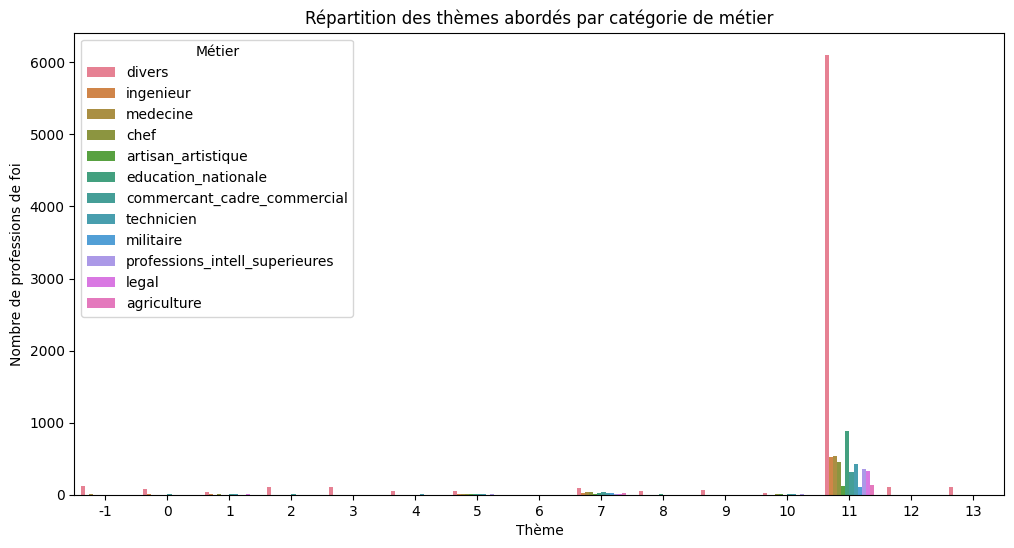

In [70]:
plt.figure(figsize=(12,6))
sns.countplot(x='theme_cluster', hue='profession_category', data=meta_et_texts)
plt.title("Répartition des thèmes abordés par catégorie de métier")
plt.xlabel("Thème")
plt.ylabel("Nombre de professions de foi")
plt.legend(title="Métier")
plt.show()

## Analyses statistiques diverses

In [71]:
contingency_table = pd.crosstab(meta_et_texts['profession_category'], meta_et_texts['theme_cluster'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")

Chi2 = 873.05, p-value = 0.0000
